# 02-llm.ipynb
- 기존 기계적인 워크플로우 -> LLM 삽입

In [19]:
from dotenv import load_dotenv

load_dotenv()

True

In [20]:
# State 정의
from typing import TypedDict, Literal, NotRequired

class TeacherState(TypedDict):
    user_input: str # 사용자 입력
    sentiment: NotRequired[Literal['positive', 'negative', 'aggressive']]  # 감정 분석
    core_msg: NotRequired[str]   # 핵심 메시지
    response: NotRequired[str]   # 최종 답변

In [39]:
from langchain.chat_models import init_chat_model
# app.invoke({'user_input': '나 너무 우울해'}) << 이렇게 실행이 됨.
# LLM 초기화 + 감정분석 Node

llm = init_chat_model('gpt-4.1-mini')


def analyze_sentiment(state: TeacherState):
    prompt = f'''
    아래 문장의 감정을 분류.
    아래 세 가지 중 한 가지 단어로만 판단.
    positive
    negative
    aggressive

    문장: {state['user_input']}
    '''
    result = llm.invoke(prompt)
    
    return {'sentiment': result.content} # 바뀐 부분만 return하면 기존 결과(user_input)와 합쳐줌.


In [40]:
# 나머지 노드
import random

def positive_node(state: TeacherState):
    msgs =['최고', '멋져', '훌륭']
    keyword = random.choice(msgs)
    return {'core_msg': keyword}

def negative_node(state: TeacherState):
    msgs =['힘내', '위로', '괜찮']
    keyword = random.choice(msgs)
    return {'core_msg': keyword}

def aggressive_node(state: TeacherState):
    return {'core_msg': '공격적인 표현은 삼가라'}

In [41]:
# 완성 node
def make_final_msg(state: TeacherState):
    prompt = f'''
    다음 사용자 입력에 맞는 답변을 생성해.
    핵심 키워드를 참조해야해.

    사용자 입력: {state['user_input']}
    사용자 입력: {state['core_msg']}
    '''

    result = llm.invoke(prompt)

    return {'response': result.content}

In [42]:
def router(state: TeacherState):
    return state['sentiment']

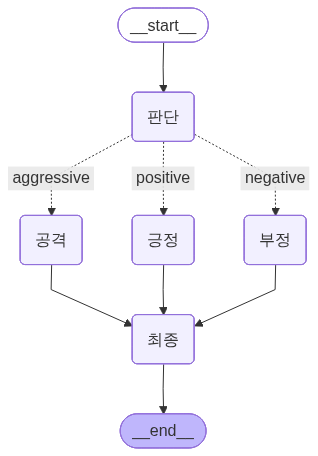

In [43]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(TeacherState)

# 노드 등록 (등록 이름, 함수 이름)
graph.add_node('판단', analyze_sentiment)

graph.add_node('긍정', positive_node)
graph.add_node('부정', negative_node)
graph.add_node('공격', aggressive_node)

graph.add_node('최종', make_final_msg)

# 엣지 등록
graph.add_edge(START, '판단')

graph.add_conditional_edges(
    '판단',
    router,
    {    # router 결과값 -> 다음 노드 이름
        'positive': '긍정',
        'negative': '부정',
        'aggressive': '공격'
    }
)

graph.add_edge('긍정', '최종')
graph.add_edge('부정', '최종')
graph.add_edge('공격', '최종')

graph.add_edge('최종', END)


app = graph.compile()

app

In [46]:
app.invoke({'user_input': '잘 잤다'})

{'user_input': '잘 잤다',
 'sentiment': 'positive',
 'core_msg': '최고',
 'response': '좋은 아침이에요! 잘 주무셨다니 기분 좋네요. 오늘도 최고로 멋진 하루 보내세요!'}